# 03 — Experiment 1: Smith convergence (H1)

**What you are looking at.** The first pre-registered experiment: do LLM
traders converge to competitive equilibrium faster than budget-constrained
random traders? Three cells of 30 sessions in *identical* markets (matched
value/cost schedules and polling order): the **ZI-C control**, and the local
8B model (**Qwen2.5-7B**, pinned revision) under two independently worded
instruction templates (**paraphrase A** and **B**). The pre-registered primary
endpoint (HYPOTHESES.md, Amendment A2) is **early-period Smith's α** — price
deviation from equilibrium over periods 1–2, pooled; a session with no early
trades scores α = +∞. Everything runs from committed logs. The frontier-model
cells are deferred (Amendment A2.vi) and will be appended under this same
protocol.


In [1]:
import math
import pandas as pd
from agentic_trading.metrics import early_alpha_from_log, h1_summary, session_metrics
from agentic_trading.runner import load_session_logs

CELLS = ("zi_c", "llm_local_a", "llm_local_b")
logs = {c: load_session_logs(f"../results/smith_h1/sessions/{c}.jsonl.gz") for c in CELLS}
metrics = {c: [session_metrics(l) for l in ls] for c, ls in logs.items()}
alphas = {c: [early_alpha_from_log(l) for l in ls] for c, ls in logs.items()}

def loss_trade_rate(log):
    values = {t["trader_id"]: t["values"] for t in log["traders"]}
    costs = {t["trader_id"]: t["costs"] for t in log["traders"]}
    nb_, ns_, losses, last_period = {}, {}, 0, 0
    for tr in log["trades"]:
        if tr["period"] != last_period:
            nb_, ns_, last_period = {}, {}, tr["period"]
        b, s = tr["buyer_id"], tr["seller_id"]
        bs = values[b][nb_.get(b, 0)] - tr["price"]
        ss = tr["price"] - costs[s][ns_.get(s, 0)]
        losses += (bs < 0) + (ss < 0)
        nb_[b] = nb_.get(b, 0) + 1
        ns_[s] = ns_.get(s, 0) + 1
    return losses / (2 * len(log["trades"])) if log["trades"] else None

def pass_rate(log):
    polls = [o["status"] for e, o in zip(log["events"], log["outcomes"])
             if e["type"] in ("submit", "cancel", "pass")]
    return polls.count("passed") / len(polls)

rows = []
for cell in CELLS:
    finite = [a for a in alphas[cell] if math.isfinite(a)]
    lr = [x for x in (loss_trade_rate(l) for l in logs[cell]) if x is not None]
    rows.append({
        "cell": cell,
        "sessions": len(logs[cell]),
        "mean early alpha (finite)": round(sum(finite) / len(finite), 1) if finite else None,
        "zero-early-trade sessions": len(alphas[cell]) - len(finite),
        "mean efficiency": round(sum(m["efficiency"] for m in metrics[cell]) / len(metrics[cell]), 3),
        "trades/session": round(sum(m["n_trades"] for m in metrics[cell]) / len(metrics[cell]), 1),
        "loss-trade rate": round(sum(lr) / len(lr), 3),
        "pass rate": round(sum(pass_rate(l) for l in logs[cell]) / len(logs[cell]), 3),
        "validity": (round(sum(l["meta"]["validity"]["validity_rate"] for l in logs[cell]) / len(logs[cell]), 3)
                     if cell != "zi_c" else None),
    })
pd.DataFrame(rows).set_index("cell")

,sessions,mean early alpha (finite),zero-early-trade sessions,mean efficiency,trades/session,loss-trade rate,pass rate,validity
cell,,,,,,,,
zi_c,30,36.5,0,0.918,32.7,0.000,0.026,NaN
llm_local_a,30,61.4,3,0.223,14.1,0.308,0.945,0.998
llm_local_b,30,51.5,0,0.177,51.2,0.464,0.896,0.999


## The pre-registered H1 test

Per paraphrase: one-sided Mann-Whitney (LLM early-α stochastically smaller
than ZI-C's, +∞ sessions ranked most-divergent). The **conjunction p** (the
larger of the two paraphrase p-values) is H1's contribution to the Holm family
once H2 and H3 exist. Secondary: efficiency non-inferiority — the bootstrap
95% lower bound of (LLM − ZI-C) mean efficiency must clear −0.05.


In [2]:
summary = h1_summary(logs["zi_c"], {"A": logs["llm_local_a"], "B": logs["llm_local_b"]})
for name, cell in summary["paraphrases"].items():
    print(f"paraphrase {name}: mean early alpha {cell['mean_early_alpha']:.1f} "
          f"(ZI-C {summary['zi_c']['mean_early_alpha']:.1f}), "
          f"U={cell['mannwhitney_u']:.0f}, one-sided p={cell['p_alpha_less']:.4g}; "
          f"efficiency diff lower95={cell['efficiency_diff_lower95']:+.3f} "
          f"-> non-inferior: {cell['efficiency_non_inferior']}")
print(f"\nconjunction p (enters Holm at Stage 6): {summary['conjunction_p']:.4g}")
print(f"H1 direction supported at 0.05 in BOTH paraphrases: {summary['h1_direction_supported']}")

paraphrase A: mean early alpha 61.4 (ZI-C 36.5), U=642, one-sided p=0.9978; efficiency diff lower95=-0.743 -> non-inferior: False
paraphrase B: mean early alpha 51.5 (ZI-C 36.5), U=566, one-sided p=0.9575; efficiency diff lower95=-0.834 -> non-inferior: False

conjunction p (enters Holm at Stage 6): 0.9978
H1 direction supported at 0.05 in BOTH paraphrases: False


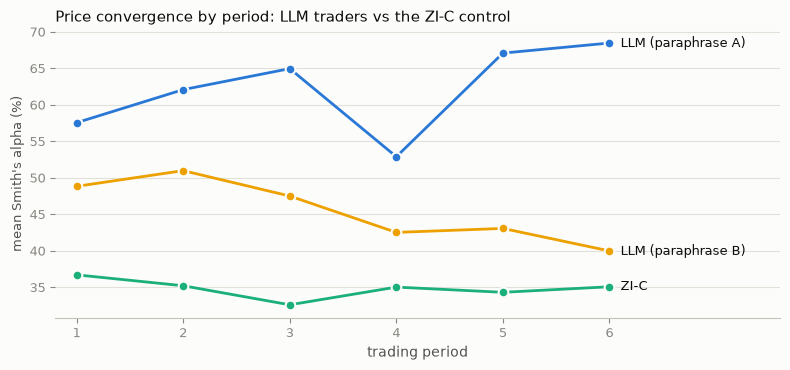

In [3]:
import matplotlib.pyplot as plt

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
COLOR = {"zi_c": "#1baf7a", "llm_local_a": "#2a78d6", "llm_local_b": "#eda100"}
LABEL = {"zi_c": "ZI-C", "llm_local_a": "LLM (paraphrase A)", "llm_local_b": "LLM (paraphrase B)"}

def style_axis(ax):
    ax.set_facecolor(SURFACE)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9)

def mean_alpha_by_period(cell, period):
    xs = [m["periods"][period - 1]["alpha"] for m in metrics[cell]
          if m["periods"][period - 1]["alpha"] is not None]
    return sum(xs) / len(xs) if xs else None

fig, ax = plt.subplots(figsize=(8, 3.8))
fig.patch.set_facecolor(SURFACE)
style_axis(ax)
periods = range(1, 7)
for cell in CELLS:
    ys = [mean_alpha_by_period(cell, p) for p in periods]
    ax.plot(periods, ys, color=COLOR[cell], linewidth=2, marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=1.5, label=LABEL[cell])
    ax.annotate(LABEL[cell], (6, ys[-1]), xytext=(8, 0), textcoords="offset points",
                color=INK, fontsize=9, va="center")
ax.set_xlim(0.8, 7.6)
ax.set_xticks(list(periods))
ax.set_xlabel("trading period", color=INK2, fontsize=10)
ax.set_ylabel("mean Smith's alpha (%)", color=INK2, fontsize=9)
ax.set_title("Price convergence by period: LLM traders vs the ZI-C control",
             loc="left", color=INK, fontsize=11)
plt.tight_layout(); plt.show()

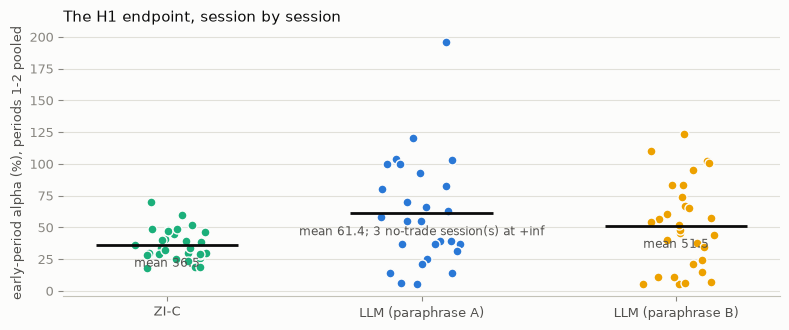

In [4]:
# Early-period alpha per session (the H1 endpoint), finite values as dots.
import random as _r
fig, ax = plt.subplots(figsize=(8, 3.4))
fig.patch.set_facecolor(SURFACE)
style_axis(ax)
jitter = _r.Random(0)
for x, cell in enumerate(CELLS):
    finite = [a for a in alphas[cell] if math.isfinite(a)]
    n_inf = len(alphas[cell]) - len(finite)
    xs = [x + jitter.uniform(-0.16, 0.16) for _ in finite]
    ax.scatter(xs, finite, s=42, color=COLOR[cell], edgecolor=SURFACE, linewidth=1, zorder=3)
    mean = sum(finite) / len(finite)
    ax.hlines(mean, x - 0.28, x + 0.28, color=INK, linewidth=2, zorder=4)
    note = f"mean {mean:.1f}" + (f"; {n_inf} no-trade session(s) at +inf" if n_inf else "")
    ax.annotate(note, (x, mean), xytext=(0, -16), textcoords="offset points",
                ha="center", color=INK2, fontsize=8.5)
ax.set_xticks(range(len(CELLS)))
ax.set_xticklabels([LABEL[c] for c in CELLS], color=INK2, fontsize=9)
ax.set_ylabel("early-period alpha (%), periods 1-2 pooled", color=INK2, fontsize=9)
ax.set_title("The H1 endpoint, session by session", loc="left", color=INK, fontsize=11)
plt.tight_layout(); plt.show()

## Where does the difference live? (decomposition + exploratory)

The pre-registered secondaries decompose any gap into **loss avoidance**
(ZI-C happily trades at a loss against its schedule; a reasoning trader should
not) and **surplus capture** (how much of the pie gets realized at all, which
depends on trading enough). The exploratory moderators (persona, memory
window; paraphrase A, 15 sessions, descriptive only — Amendment A2.v) ask
whether prompting changes that picture.


In [5]:
explore_cells = ("persona_risk_averse", "persona_aggressive", "memory_recent")
explore_logs = {c: load_session_logs(f"../results/smith_explore/sessions/{c}.jsonl.gz")
                for c in explore_cells}
rows = []
for name, ls in list(logs.items())[1:] + list(explore_logs.items()):
    finite = [a for a in (early_alpha_from_log(l) for l in ls) if math.isfinite(a)]
    ms = [session_metrics(l) for l in ls]
    rows.append({
        "cell": name,
        "n": len(ls),
        "mean early alpha": round(sum(finite) / len(finite), 1) if finite else float("nan"),
        "no-trade sessions": len(ls) - len(finite),
        "mean efficiency": round(sum(m["efficiency"] for m in ms) / len(ms), 3),
        "trades/session": round(sum(m["n_trades"] for m in ms) / len(ms), 1),
        "pass rate": round(sum(pass_rate(l) for l in ls) / len(ls), 3),
        "loss-trade rate": round(sum(x for x in (loss_trade_rate(l) for l in ls) if x is not None)
                                 / max(1, sum(1 for l in ls if l["trades"])), 3),
    })
pd.DataFrame(rows).set_index("cell")

,n,mean early alpha,no-trade sessions,mean efficiency,trades/session,pass rate,loss-trade rate
cell,,,,,,,
llm_local_a,30,61.4,3,0.223,14.1,0.945,0.308
llm_local_b,30,51.5,0,0.177,51.2,0.896,0.464
persona_risk_averse,15,39.9,9,0.036,2.3,0.969,0.162
persona_aggressive,15,66.8,1,0.285,42.1,0.901,0.440
memory_recent,15,65.0,0,0.243,18.7,0.920,0.345


## Headline row 1 and the human anchor

Human double-auction markets converge fast: Smith's original sessions show
early-period α around 8–12%, falling below 5% with repetition (Smith 1962;
e.g. his first test market's per-period α sequence 11.8, 8.1, 5.2, 5.5, 3.5).
Those numbers are a **directional anchor, not an equivalence claim** — our
markets differ in incentives (no real money), subject counts, homogeneous
same-model self-play, and polling institution (see the Stage 5 comparability
table). The gate cell below pins every displayed number to `CLAIMS.md`.


In [6]:
a = summary["paraphrases"]["A"]
b = summary["paraphrases"]["B"]
zic_alpha = summary["zi_c"]["mean_early_alpha"]
non_inferior_both = "yes" if (a["efficiency_non_inferior"] and b["efficiency_non_inferior"]) else "no"
conj = summary["conjunction_p"]

from agentic_trading.reproduce import verify_claims
print(verify_claims("03_smith_convergence", {
    "H1-1": f"{a['mean_early_alpha']:.1f}",
    "H1-2": f"{b['mean_early_alpha']:.1f}",
    "H1-3": f"{zic_alpha:.1f}",
    "H1-4": "<0.001" if conj < 0.001 else f"{conj:.3f}",
    "H1-5": non_inferior_both,
    "H1-6": f"{sum(m['efficiency'] for m in metrics['llm_local_a']) / 30:.2f}",
    "H1-7": f"{sum(m['efficiency'] for m in metrics['llm_local_b']) / 30:.2f}",
    "H1-8": f"{sum(m['efficiency'] for m in metrics['zi_c']) / 30:.2f}",
}))

OK: 8 claim(s) verified against CLAIMS.md
